# Weather Forecasting Model Development

## Objective

This notebook builds and compares multiple forecasting models using the `last_updated` timestamp as the time series feature.

The goal is to forecast temperature trends and evaluate model performance using standard regression metrics.

This notebook includes:
- Time series preparation
- Baseline forecasting model
- Machine learning forecasting models
- Multiple model comparison
- Ensemble forecasting
- Model evaluation using MAE, RMSE, MAPE, and R²

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

# Load Processed Dataset

The cleaned dataset generated during preprocessing is loaded for model development.

In [2]:
DATA_PATH = Path("../data/processed/weather_cleaned.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (139948, 51)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_carbon_monoxide,air_quality_ozone,air_quality_nitrogen_dioxide,air_quality_sulphur_dioxide,air_quality_pm2.5,air_quality_pm10,air_quality_us_epa_index,air_quality_gb_defra_index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,day,hour,day_of_year,weekday,is_weekend,is_day,season,temp_difference
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,2024,5,16,13,137,Thursday,0,1,Spring,-1.3
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55,2024,5,16,10,137,Thursday,0,1,Spring,0.0
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55,2024,5,16,9,137,Thursday,0,1,Spring,1.6
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55,2024,5,16,10,137,Thursday,0,1,Spring,-2.5
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55,2024,5,16,9,137,Thursday,0,1,Spring,2.7


# Datetime Conversion

The `last_updated` feature is converted into datetime format and used as the main time index for forecasting.

In [3]:
df["last_updated"] = pd.to_datetime(df["last_updated"], errors="coerce")

print("Date range:", df["last_updated"].min(), "to", df["last_updated"].max())
print("Invalid datetime values:", df["last_updated"].isna().sum())

Date range: 2024-05-16 01:45:00 to 2026-05-07 19:30:00
Invalid datetime values: 0


# Forecasting Target

The forecasting target selected for this project is `temperature_celsius`.

Temperature is chosen because it is a core weather variable, shows clear seasonal behavior, and is suitable for time series forecasting.

# City Selection for Forecasting

Forecasting is performed on a single location to maintain temporal consistency and reduce geographical noise.

The city with the highest number of observations is selected for time series forecasting.

In [4]:
city_counts = (
    df["location_name"]
    .value_counts()
    .reset_index()
)

city_counts.columns = ["location_name", "record_count"]

city_counts.head(10)

,location_name,record_count
0,Kabul,720
1,Bujumbura,720
2,N'djamena,720
3,Malabo,720
4,Asmara,720
5,Suva,720
6,Accra,720
7,Vatican City,720
8,Baghdad,720
9,Tokyo,720


# Time Series Preparation

The forecasting analysis is performed using weather observations from Tokyo.

Using a single city helps maintain temporal consistency and improves forecasting reliability by avoiding geographical and climatic mixing effects.

In [5]:
city_df = df[df["location_name"] == "Tokyo"].copy()

print("Shape:", city_df.shape)

city_df.head()

Shape: (720, 51)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_carbon_monoxide,air_quality_ozone,air_quality_nitrogen_dioxide,air_quality_sulphur_dioxide,air_quality_pm2.5,air_quality_pm10,air_quality_us_epa_index,air_quality_gb_defra_index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,day,hour,day_of_year,weekday,is_weekend,is_day,season,temp_difference
85,Japan,Tokyo,35.69,139.69,Asia/Tokyo,1715849100,2024-05-16 17:45:00,24.0,75.2,Partly cloudy,20.6,33.1,200,SSW,1001.0,29.56,0.00,0.00,47,25,25.3,77.6,10.0,6.0,6.0,32.5,52.2,317.1,100.1,31.2,17.9,15.8,18.4,2,2,04:35 AM,06:40 PM,11:48 AM,12:56 AM,Waxing Gibbous,55,2024,5,16,17,137,Thursday,0,1,Spring,1.3
280,Japan,Tokyo,35.69,139.69,Asia/Tokyo,1715868000,2024-05-16 23:00:00,18.3,64.9,Clear,11.9,19.1,190,S,1005.0,29.68,0.00,0.00,44,0,18.3,64.9,16.0,9.0,1.0,34.6,55.7,277.0,103.0,25.0,15.1,9.5,11.9,1,1,04:35 AM,06:40 PM,11:48 AM,12:56 AM,Waxing Gibbous,55,2024,5,16,23,137,Thursday,0,0,Spring,0.0
475,Japan,Tokyo,35.69,139.69,Asia/Tokyo,1715961600,2024-05-18 01:00:00,18.0,64.4,Clear,2.5,4.0,140,SE,1016.0,30.00,0.00,0.00,77,0,18.0,64.4,10.0,6.0,1.0,9.0,14.5,627.5,0.0,106.9,25.8,36.8,45.1,2,4,04:34 AM,06:41 PM,12:45 PM,01:21 AM,Waxing Gibbous,64,2024,5,18,1,139,Saturday,1,0,Spring,0.0
667,Japan,Tokyo,35.69,139.69,Asia/Tokyo,1716042600,2024-05-18 23:30:00,20.0,68.0,Clear,6.9,11.2,170,S,1018.0,30.06,0.00,0.00,78,0,20.0,68.0,10.0,6.0,1.0,11.2,18.1,480.7,57.2,90.5,31.0,62.5,73.9,3,8,04:34 AM,06:42 PM,01:42 PM,01:44 AM,Waxing Gibbous,73,2024,5,18,23,139,Saturday,1,0,Spring,0.0
861,Japan,Tokyo,35.69,139.69,Asia/Tokyo,1716127200,2024-05-19 23:00:00,19.2,66.6,Light rain,5.6,9.0,280,W,1018.0,30.06,1.07,0.04,76,100,19.2,66.6,9.7,6.0,1.0,8.6,13.9,460.6,54.4,73.3,26.2,96.3,101.4,4,10,04:33 AM,06:42 PM,02:37 PM,02:06 AM,Waxing Gibbous,81,2024,5,19,23,140,Sunday,1,0,Spring,0.0


In [6]:
city_df = city_df.sort_values("last_updated")

city_df = city_df.reset_index(drop=True)

In [7]:
daily_temp = (
    city_df
    .set_index("last_updated")
    .resample("D")["temperature_celsius"]
    .mean()
    .reset_index()
)

daily_temp.head()

,last_updated,temperature_celsius
0,2024-05-16,21.15
1,2024-05-17,NaN
2,2024-05-18,19.00
3,2024-05-19,19.20
4,2024-05-20,20.00


## Daily Temperature Time Series

The daily average temperature trend is visualized to understand temporal behavior and seasonal patterns before forecasting.

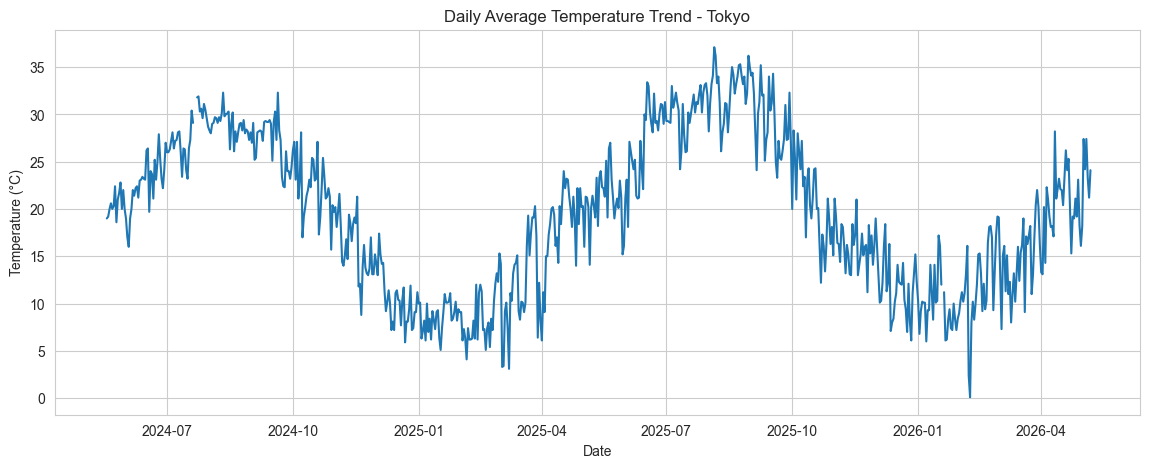

In [8]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_temp["last_updated"],
    daily_temp["temperature_celsius"]
)

plt.title("Daily Average Temperature Trend - Tokyo")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.show()

### Observations

- The daily temperature series exhibits a clear seasonal pattern across the observed time period.
- Higher temperatures occur during mid-year periods, while lower temperatures appear near the beginning and end of the year.
- The repeating cyclical behavior suggests strong annual seasonality in Tokyo’s climate.
- Short-term fluctuations are also visible, reflecting day-to-day weather variability.
- The presence of temporal structure and seasonality indicates that the dataset is suitable for time series forecasting.

# Feature Engineering for Forecasting

Additional time-series features are created to help forecasting models capture temporal dependencies and seasonal behavior.

The engineered features include:
- Lag temperature values
- Rolling temperature averages
- Month and day-based temporal indicators

In [9]:
forecast_df = daily_temp.copy()

# Lag features
forecast_df["temp_lag_1"] = forecast_df["temperature_celsius"].shift(1)
forecast_df["temp_lag_7"] = forecast_df["temperature_celsius"].shift(7)

# Rolling averages
forecast_df["rolling_mean_7"] = (
    forecast_df["temperature_celsius"]
    .rolling(window=7)
    .mean()
)

forecast_df["rolling_mean_30"] = (
    forecast_df["temperature_celsius"]
    .rolling(window=30)
    .mean()
)

# Time-based features
forecast_df["month"] = forecast_df["last_updated"].dt.month
forecast_df["day_of_year"] = forecast_df["last_updated"].dt.dayofyear

forecast_df.head()

,last_updated,temperature_celsius,temp_lag_1,temp_lag_7,rolling_mean_7,rolling_mean_30,month,day_of_year
0,2024-05-16,21.15,NaN,NaN,NaN,NaN,5,137
1,2024-05-17,NaN,21.15,NaN,NaN,NaN,5,138
2,2024-05-18,19.00,NaN,NaN,NaN,NaN,5,139
3,2024-05-19,19.20,19.00,NaN,NaN,NaN,5,140
4,2024-05-20,20.00,19.20,NaN,NaN,NaN,5,141


In [10]:
forecast_df = forecast_df.dropna()

print("Final forecasting dataset shape:", forecast_df.shape)

Final forecasting dataset shape: (630, 8)


# Train-Test Split

The dataset is split chronologically to preserve temporal order and avoid data leakage.

Earlier observations are used for training, while later observations are reserved for forecasting evaluation.

In [11]:
feature_cols = [
    "temp_lag_1",
    "temp_lag_7",
    "rolling_mean_7",
    "rolling_mean_30",
    "month",
    "day_of_year"
]

X = forecast_df[feature_cols]

y = forecast_df["temperature_celsius"]

In [12]:
split_index = int(len(forecast_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (504, 6)
Test size: (126, 6)


# Forecasting Models

Multiple forecasting models are developed and compared to evaluate predictive performance.

The models include:
- Baseline Moving Average model
- Random Forest Regressor
- XGBoost Regressor
- Ensemble Forecasting model

In [13]:
baseline_pred = X_test["rolling_mean_7"]

In [27]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    y_true_safe = np.where(y_true == 0, np.nan, y_true)
    mape = np.nanmean(np.abs((y_true - y_pred) / y_true_safe)) * 100

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

In [28]:
baseline_results = evaluate_model(
    "Baseline Moving Average",
    y_test,
    baseline_pred
)

baseline_results

{'Model': 'Baseline Moving Average',
 'MAE': 2.4673469387755103,
 'RMSE': np.float64(3.0040847906174863),
 'R2': 0.6665450154834367,
 'MAPE': np.float64(18.66408193696121)}

## Random Forest Forecasting Model

A Random Forest Regressor is used to capture nonlinear relationships and temporal dependencies within the weather data.

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [30]:
rf_pred = rf_model.predict(X_test)

In [31]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

rf_results

{'Model': 'Random Forest',
 'MAE': 2.6768962712767883,
 'RMSE': np.float64(3.2777087674907865),
 'R2': 0.6030337668340731,
 'MAPE': np.float64(19.929882000438223)}

## XGBoost Forecasting Model

XGBoost is applied as an advanced gradient boosting model for temperature forecasting due to its strong predictive performance and ability to model complex nonlinear patterns.`

In [32]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [33]:
xgb_pred = xgb_model.predict(X_test)

In [34]:
xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)

xgb_results

{'Model': 'XGBoost',
 'MAE': 2.7886468720814537,
 'RMSE': np.float64(3.513063437469386),
 'R2': 0.5439790184863067,
 'MAPE': np.float64(21.109754872529027)}

## Ensemble Forecasting Model

An ensemble forecasting approach is implemented by combining predictions from multiple models.

Ensemble methods can improve robustness and reduce individual model bias by leveraging the strengths of different forecasting techniques.

In [35]:
ensemble_pred = (
    baseline_pred.values +
    rf_pred +
    xgb_pred
) / 3

In [36]:
ensemble_results = evaluate_model(
    "Ensemble Model",
    y_test,
    ensemble_pred
)

ensemble_results

{'Model': 'Ensemble Model',
 'MAE': 2.5035225328498045,
 'RMSE': np.float64(3.1183135748389135),
 'R2': 0.6407039760085921,
 'MAPE': np.float64(18.811554160874298)}

# Forecasting Model Comparison

The performance of all forecasting models is compared using multiple evaluation metrics.

In [37]:
results_df = pd.DataFrame([
    baseline_results,
    rf_results,
    xgb_results,
    ensemble_results
])

results_df

,Model,MAE,RMSE,R2,MAPE
0,Baseline Moving Average,2.467347,3.004085,0.666545,18.664082
1,Random Forest,2.676896,3.277709,0.603034,19.929882
2,XGBoost,2.788647,3.513063,0.543979,21.109755
3,Ensemble Model,2.503523,3.118314,0.640704,18.811554


### Model Comparison Observations

- The Baseline Moving Average model achieved the lowest RMSE and MAE among all tested models.
- This indicates that recent temperature history is highly informative for short-term forecasting.
- Random Forest and XGBoost captured nonlinear patterns but did not outperform the simpler baseline model.
- The ensemble model improved over the individual machine learning models but remained slightly weaker than the baseline.
- This result suggests that Tokyo’s daily temperature series has strong temporal smoothness and seasonality, which simple rolling-average methods can capture effectively.

In [38]:
results_df = results_df.sort_values(
    by="RMSE"
)

results_df

,Model,MAE,RMSE,R2,MAPE
0,Baseline Moving Average,2.467347,3.004085,0.666545,18.664082
3,Ensemble Model,2.503523,3.118314,0.640704,18.811554
1,Random Forest,2.676896,3.277709,0.603034,19.929882
2,XGBoost,2.788647,3.513063,0.543979,21.109755


# Actual vs Forecasted Temperature

The following visualization compares actual temperature observations with forecasted values from the best-performing model.

Although advanced machine learning models were tested, the best-performing model was selected based on evaluation metrics rather than model complexity. This reflects a practical data science approach where simpler models are preferred when they provide stronger and more interpretable results.`

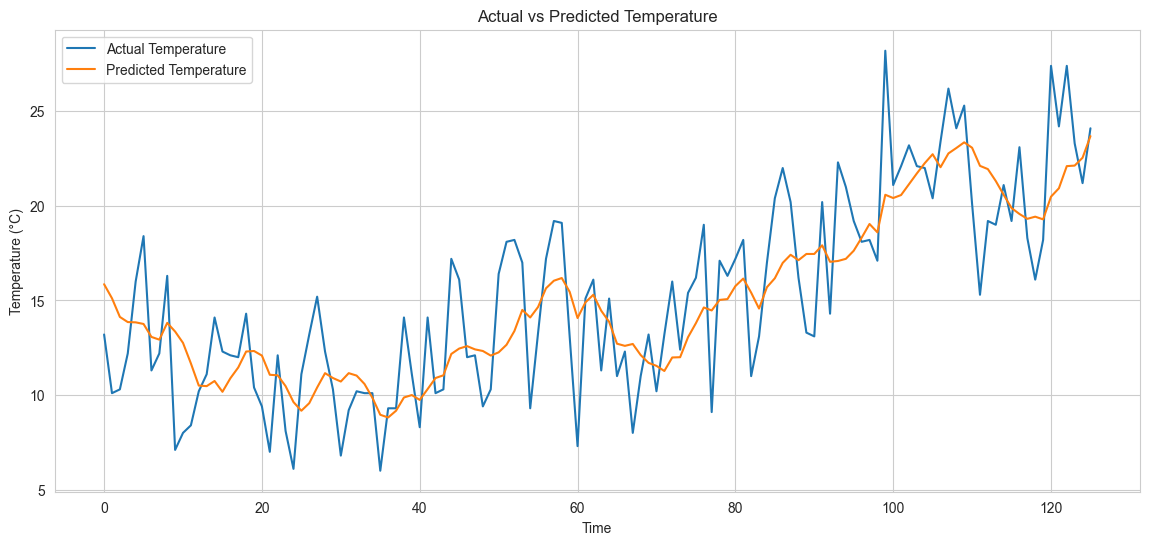

In [39]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values,
    label="Actual Temperature"
)

plt.plot(
    baseline_pred.values,
    label="Predicted Temperature"
)

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.legend()

plt.show()

### Forecast Visualization Observations

- The predicted temperature trend follows the overall movement of the actual temperature series.
- The model captures the general seasonal decline and short-term temperature movement reasonably well.
- Some sharp daily fluctuations are not fully captured, which is expected from a moving average-based forecasting approach.
- The visualization supports the quantitative results and shows that the model performs well for general temperature trend forecasting.

# Final Conclusion

This notebook developed and compared multiple forecasting approaches for daily temperature prediction using the `last_updated` timestamp as the time series feature.

Key outcomes:
- A clean daily temperature time series was created for Tokyo.
- Lag and rolling-window features were engineered to capture temporal dependencies.
- Multiple models were evaluated, including a baseline moving average model, Random Forest, XGBoost, and an ensemble model.
- The baseline moving average model achieved the best performance, indicating strong temporal smoothness in the temperature series.
- The ensemble model improved robustness compared to individual machine learning models.
- The forecasting workflow demonstrates a complete time series modeling pipeline with model comparison, evaluation, and interpretation.

Overall, the results show that simple temporal models can be highly effective when the target variable has strong seasonal and rolling patterns.